# Análisis del Radio de Giro — Simulación de Dinámica Molecular

**Sistema:** Tripéptido **ACE-ALA-ARG-VAL-NME** (ARV) en solución acuosa  
**Campo de fuerzas:** CHARMM27 · **Modelo de agua:** TIP3P  
**Herramienta:** GROMACS · `gmx gyrate`  
**Temperaturas simuladas:** 298 K y 400 K

---

## 1. Importación de librerías y configuración de estilo

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import sem

# ── Estilo publicación científica ──────────────────────────────────────────────
plt.rcParams.update({
    'font.family':        'serif',
    'font.size':          11,
    'axes.labelsize':     12,
    'axes.titlesize':     12,
    'axes.linewidth':     1.2,
    'xtick.direction':    'in',
    'ytick.direction':    'in',
    'xtick.major.width':  1.1,
    'ytick.major.width':  1.1,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'legend.framealpha': 0.9,
    'legend.fontsize':   10,
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
})

# Columnas: tiempo (ps), Rg (nm), Rg-x (nm), Rg-y (nm), Rg-z (nm)
COLS = ['time_ps', 'Rg', 'Rg_x', 'Rg_y', 'Rg_z']

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 2. Carga de datos

In [9]:
def load_xvg(filepath, col_names):
    """Lee un archivo .xvg de GROMACS ignorando cabeceras (líneas con '@' o '#').
    El tiempo devuelto por gmx gyrate ya está en ps.
    """
    data = []
    with open(filepath) as fh:
        for line in fh:
            line = line.strip()
            if line.startswith('#') or line.startswith('@') or not line:
                continue
            data.append(list(map(float, line.split())))
    df = pd.DataFrame(data, columns=col_names)
    return df

df_298 = load_xvg('gyrate-298.xvg',      COLS)
df_400 = load_xvg('gyrate-400.xvg', COLS)

print(f'298 K → {len(df_298)} frames  |  tiempo: {df_298.time_ps.min():.3f} – {df_298.time_ps.max():.3f} ps')
print(f'400 K → {len(df_400)} frames  |  tiempo: {df_400.time_ps.min():.3f} – {df_400.time_ps.max():.3f} ps')
df_298.head(3)


298 K → 2001 frames  |  tiempo: 0.000 – 2.000 ps
400 K → 2001 frames  |  tiempo: 0.000 – 2.000 ps


,time_ps,Rg,Rg_x,Rg_y,Rg_z
0,0.000,0.448990,0.354232,0.348563,0.395231
1,0.001,0.448996,0.354230,0.348517,0.395287
2,0.002,0.449007,0.354230,0.348478,0.395347


## 3. Gráfica individual — 298 K

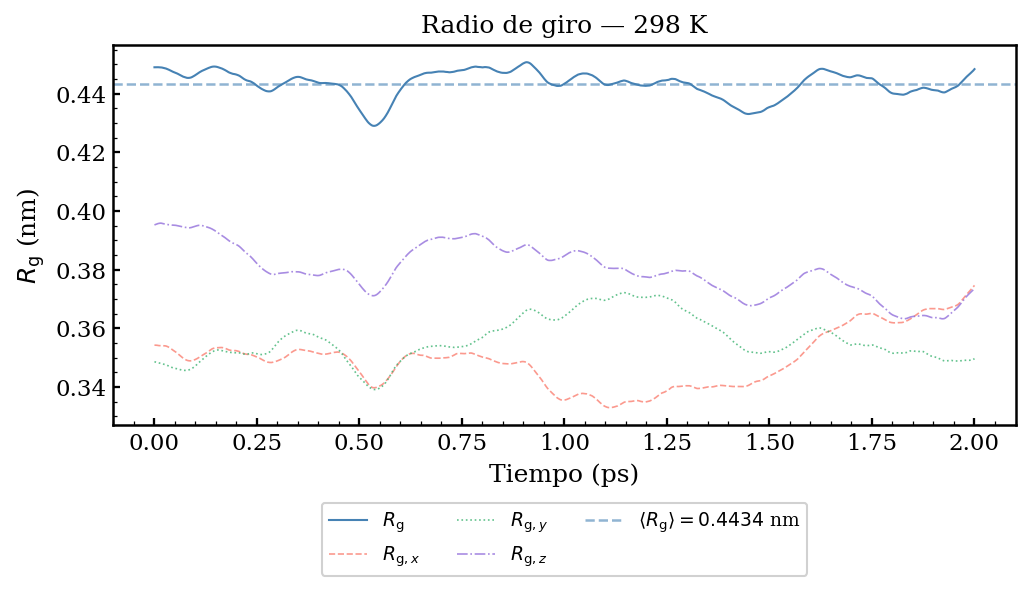

Figura guardada como gyrate_298K.png


In [10]:
fig, ax = plt.subplots(figsize=(7, 4.2))

ax.plot(df_298['time_ps'], df_298['Rg'],   color='steelblue',     lw=1.0, label=r'$R_{\mathrm{g}}$')
ax.plot(df_298['time_ps'], df_298['Rg_x'], color='salmon',        lw=0.8, ls='--', alpha=0.8, label=r'$R_{\mathrm{g},x}$')
ax.plot(df_298['time_ps'], df_298['Rg_y'], color='mediumseagreen', lw=0.8, ls=':', alpha=0.8, label=r'$R_{\mathrm{g},y}$')
ax.plot(df_298['time_ps'], df_298['Rg_z'], color='mediumpurple',   lw=0.8, ls='-.', alpha=0.8, label=r'$R_{\mathrm{g},z}$')

mean_298 = df_298['Rg'].mean()
ax.axhline(mean_298, color='steelblue', lw=1.2, ls='--', alpha=0.6,
           label=fr'$\langle R_{{\mathrm{{g}}}}\rangle = {mean_298:.4f}$ nm')

ax.set_xlabel('Tiempo (ps)')
ax.set_ylabel(r'$R_{\mathrm{g}}$ (nm)')
ax.set_title('Radio de giro — 298 K')
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=3, fontsize=9)

plt.tight_layout()
plt.savefig('gyrate_298K.png')
plt.show()
print('Figura guardada como gyrate_298K.png')


## 4. Gráfica individual — 400 K

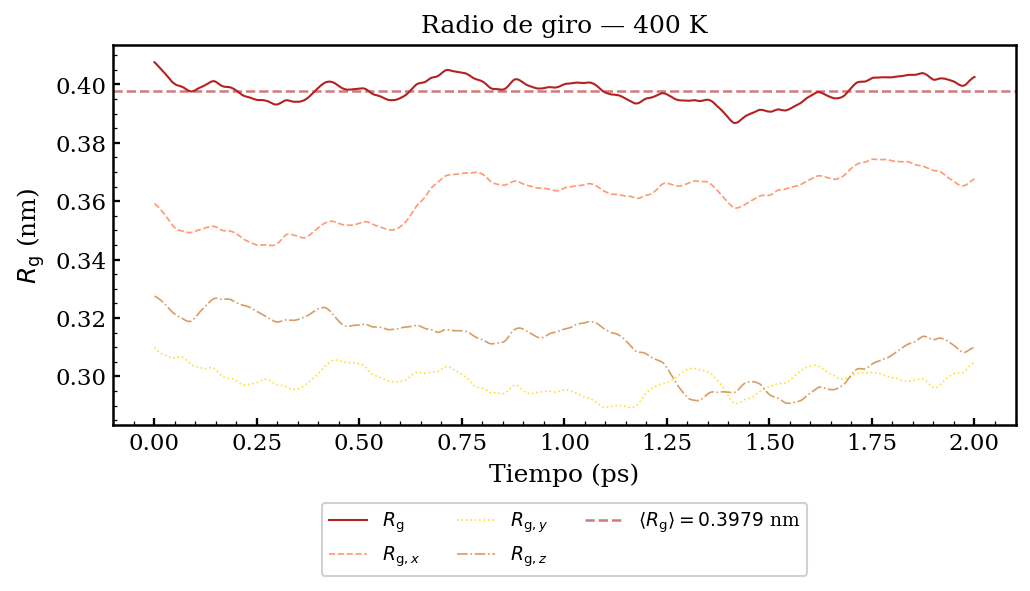

Figura guardada como gyrate_400K_plot.png


In [11]:
fig, ax = plt.subplots(figsize=(7, 4.2))

ax.plot(df_400['time_ps'], df_400['Rg'],   color='firebrick', lw=1.0, label=r'$R_{\mathrm{g}}$')
ax.plot(df_400['time_ps'], df_400['Rg_x'], color='coral',     lw=0.8, ls='--', alpha=0.8, label=r'$R_{\mathrm{g},x}$')
ax.plot(df_400['time_ps'], df_400['Rg_y'], color='gold',      lw=0.8, ls=':', alpha=0.8, label=r'$R_{\mathrm{g},y}$')
ax.plot(df_400['time_ps'], df_400['Rg_z'], color='peru',      lw=0.8, ls='-.', alpha=0.8, label=r'$R_{\mathrm{g},z}$')

mean_400 = df_400['Rg'].mean()
ax.axhline(mean_400, color='firebrick', lw=1.2, ls='--', alpha=0.6,
           label=fr'$\langle R_{{\mathrm{{g}}}}\rangle = {mean_400:.4f}$ nm')

ax.set_xlabel('Tiempo (ps)')
ax.set_ylabel(r'$R_{\mathrm{g}}$ (nm)')
ax.set_title('Radio de giro — 400 K')
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=3, fontsize=9)

plt.tight_layout()
plt.savefig('gyrate_400K_plot.png')
plt.show()
print('Figura guardada como gyrate_400K_plot.png')


## 6. Gráfica comparativa — panel único superpuesto

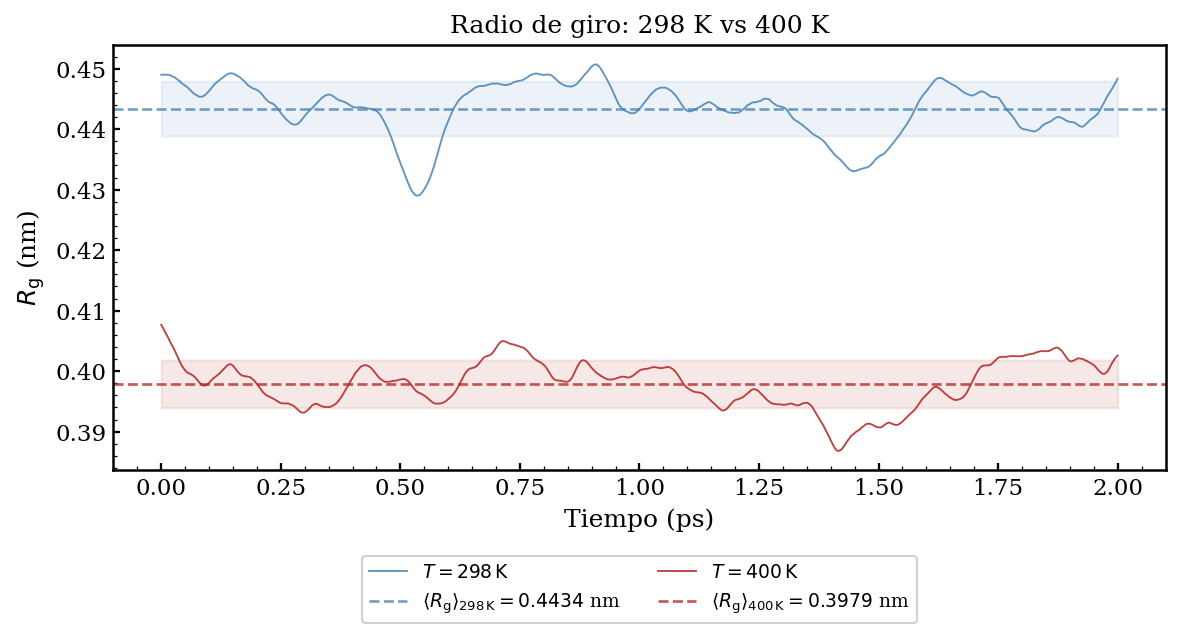

Figura guardada como gyrate_comparison_overlay.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))

for df, T, col in [(df_298, 298, 'steelblue'), (df_400, 400, 'firebrick')]:
    mean_val = df['Rg'].mean()
    std_val  = df['Rg'].std()

    ax.plot(df['time_ps'], df['Rg'], color=col, lw=0.9, alpha=0.85,
            label=rf'$T = {T}\,\mathrm{{K}}$')
    ax.axhline(mean_val, color=col, lw=1.3, ls='--', alpha=0.75,
               label=rf'$\langle R_{{\mathrm{{g}}}}\rangle_{{\mathrm{{{T}\,K}}}} = {mean_val:.4f} \pm {std_val:.4f}$ nm')
    ax.fill_between(df['time_ps'],
                    mean_val - std_val, mean_val + std_val,
                    color=col, alpha=0.10)

ax.set_xlabel('Tiempo (ps)')
ax.set_ylabel(r'$R_{\mathrm{g}}$ (nm)')
ax.set_title('Radio de giro: 298 K vs 400 K')
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2, fontsize=9)

plt.tight_layout()
plt.savefig('gyrate_comparison_overlay.png')
plt.show()
print('Figura guardada como gyrate_comparison_overlay.png')


## 7. Resumen estadístico completo

In [13]:
final_rows = []
for df, T in [(df_298, 298), (df_400, 400)]:
    for col in ['Rg', 'Rg_x', 'Rg_y', 'Rg_z']:
        final_rows.append({
            'T (K)':        T,
            'Componente':   col,
            '⟨Rg⟩ (nm)':   round(df[col].mean(), 5),
            'σ(Rg) (nm)':   round(df[col].std(),  5),
            'SEM (nm)':     round(sem(df[col]),   6),
            'Min (nm)':     round(df[col].min(),  5),
            'Max (nm)':     round(df[col].max(),  5),
        })

final_df = pd.DataFrame(final_rows)

(final_df.style
    .format({
        '⟨Rg⟩ (nm)':  '{:.5f}',
        'σ(Rg) (nm)':  '{:.5f}',
        'SEM (nm)':    '{:.6f}',
        'Min (nm)':    '{:.5f}',
        'Max (nm)':    '{:.5f}',
    })
    .set_caption('Tabla 1. Resumen estadístico del radio de giro a 298 K y 400 K.')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '13px'), ('font-weight', 'bold'),
                   ('text-align', 'left'), ('margin-bottom', '6px')]},
        {'selector': 'th',
         'props': [('background-color', '#2c3e50'), ('color', 'white'),
                   ('text-align', 'center'), ('padding', '6px 10px'),
                   ('font-size', '12px')]},
        {'selector': 'td',
         'props': [('text-align', 'center'), ('padding', '5px 10px'),
                   ('font-size', '11px')]},
        {'selector': 'tr:nth-child(even)',
         'props': [('background-color', '#f0f4f8')]},
        {'selector': 'tr:hover',
         'props': [('background-color', '#d6e4f0')]},
    ])
    .apply(lambda col: [
        'background-color: #eaf4fb' if v == 298 else 'background-color: #fdecea'
        for v in col
    ], subset=['T (K)'])
    .hide(axis='index')
)

T (K),Componente,⟨Rg⟩ (nm),σ(Rg) (nm),SEM (nm),Min (nm),Max (nm)
298,Rg,0.44341,0.00453,0.000101,0.42901,0.45072
298,Rg_x,0.34920,0.00942,0.000211,0.33293,0.37460
298,Rg_y,0.35617,0.00772,0.000173,0.33908,0.37212
298,Rg_z,0.37979,0.00869,0.000194,0.36319,0.39584
400,Rg,0.39787,0.00394,0.000088,0.38681,0.40764
400,Rg_x,0.36123,0.00830,0.000186,0.34483,0.37440
400,Rg_y,0.29867,0.00420,0.000094,0.28930,0.30992
400,Rg_z,0.31106,0.01015,0.000227,0.29076,0.32752
